# E-commerce Customer Purchase Behavior Analysis & Segmentation

## 1. Business Understanding

This project analyzes e-commerce transaction data to understand customer purchase behavior, segment customers based on purchasing patterns, and generate business recommendations for customer retention, targeting, and cross-selling strategies.

## Business Questions

1. Who are the most valuable customers?
2. Which customers are at risk of churn?
3. What products generate the most revenue?
4. What products are frequently bought together?
5. Can customers be grouped into meaningful segments?
6. What marketing strategies should be applied to each customer segment?

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [4]:
current_path = Path.cwd()

if current_path.name == "notebooks":
    BASE_DIR = current_path.parent
else:
    BASE_DIR = current_path

RAW_DATA_PATH = BASE_DIR / "data" / "raw" / "online_retail_II.xlsx"

print("BASE_DIR:", BASE_DIR)
print("RAW_DATA_PATH:", RAW_DATA_PATH)
print("File exists:", RAW_DATA_PATH.exists())

BASE_DIR: d:\AI-Learning\ecommerce-customer-segmentation
RAW_DATA_PATH: d:\AI-Learning\ecommerce-customer-segmentation\data\raw\online_retail_II.xlsx
File exists: True


## 2. Dataset Understanding

The dataset contains transaction-level records from an online retail business. Each row represents a product purchased within an invoice.

In [5]:
df = pd.read_excel(
    RAW_DATA_PATH,
    sheet_name="Year 2010-2011"
)
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
df.shape

(541910, 8)

In [7]:
df = df.rename(columns={
    "Invoice": "InvoiceNo",
    "Price": "UnitPrice",
    "Customer ID": "CustomerID"
})

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country'], dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[us]
 5   UnitPrice    541910 non-null  float64       
 6   CustomerID   406830 non-null  float64       
 7   Country      541910 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [10]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [11]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541910.000000,541910,541910.000000,406830.000000
mean,9.552234,2011-07-04 13:35:22.342307,4.611138,15287.684160
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.080957,NaN,96.759765,1713.603074


In [12]:
df[df["Quantity"] <= 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [13]:
df[df["UnitPrice"] <= 0].shape

(2517, 8)

In [14]:
df["InvoiceNo"] = df["InvoiceNo"].astype(str)

cancelled_orders = df[df["InvoiceNo"].str.startswith("C")]

cancelled_orders.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [15]:
cancelled_orders.shape

(9288, 8)

## Initial Data Observations

Initial observations from the raw dataset:

1. The dataset contains transaction-level records.
2. Some rows have missing CustomerID values.
3. Some transactions have non-positive Quantity values.
4. Some transactions have non-positive UnitPrice values.
5. Some InvoiceNo values start with "C", which may indicate cancelled transactions.
6. InvoiceDate can be used to create time-based features such as month, day of week, and hour.

These issues will be handled in the data cleaning step before performing EDA, RFM analysis, customer segmentation, and market basket analysis.

## 3. Data Cleaning

In this section, we clean the Online Retail II transaction data before performing customer behavior analysis.

The cleaning steps include:

1. Standardizing column names.
2. Removing rows with missing CustomerID.
3. Removing cancelled invoices.
4. Removing transactions with non-positive Quantity.
5. Removing transactions with non-positive UnitPrice.
6. Removing duplicate rows.
7. Converting data types.
8. Creating TotalPrice.
9. Extracting time-based features.
10. Saving the cleaned dataset.

In [16]:
df_raw = df.copy()

print("Raw data shape:", df_raw.shape)
df_raw.head()

Raw data shape: (541910, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [17]:
df_raw.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country'], dtype='str')

In [18]:
df_clean = df_raw.copy()

In [19]:
missing_summary = pd.DataFrame({
    "missing_count": df_clean.isna().sum(),
    "missing_percentage": df_clean.isna().mean() * 100
})

missing_summary.sort_values(by="missing_percentage", ascending=False)

,missing_count,missing_percentage
CustomerID,135080,24.926648
Description,1454,0.268310
StockCode,0,0.000000
InvoiceNo,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
Country,0,0.000000


In [20]:
rows_before = df_clean.shape[0]

df_clean = df_clean.dropna(subset=["CustomerID"]).copy()

rows_after = df_clean.shape[0]

print("Rows before removing missing CustomerID:", rows_before)
print("Rows after removing missing CustomerID:", rows_after)
print("Removed rows:", rows_before - rows_after)

Rows before removing missing CustomerID: 541910
Rows after removing missing CustomerID: 406830
Removed rows: 135080


In [21]:
df_clean["InvoiceNo"] = df_clean["InvoiceNo"].astype(str)

cancelled_orders = df_clean[df_clean["InvoiceNo"].str.startswith("C")]

print("Cancelled transaction rows:", cancelled_orders.shape[0])
cancelled_orders.head()

Cancelled transaction rows: 8905


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [22]:
rows_before = df_clean.shape[0]

df_clean = df_clean[~df_clean["InvoiceNo"].str.startswith("C")].copy()

rows_after = df_clean.shape[0]

print("Rows before removing cancelled invoices:", rows_before)
print("Rows after removing cancelled invoices:", rows_after)
print("Removed rows:", rows_before - rows_after)

Rows before removing cancelled invoices: 406830
Rows after removing cancelled invoices: 397925
Removed rows: 8905


In [23]:
invalid_quantity = df_clean[df_clean["Quantity"] <= 0]

print("Rows with Quantity <= 0:", invalid_quantity.shape[0])
invalid_quantity.head()

Rows with Quantity <= 0: 0


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [24]:
invalid_price = df_clean[df_clean["UnitPrice"] <= 0]

print("Rows with UnitPrice <= 0:", invalid_price.shape[0])
invalid_price.head()

Rows with UnitPrice <= 0: 40


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911.0,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom


In [25]:
rows_before = df_clean.shape[0]

df_clean = df_clean[df_clean["UnitPrice"] > 0].copy()

rows_after = df_clean.shape[0]

print("Rows before removing invalid UnitPrice:", rows_before)
print("Rows after removing invalid UnitPrice:", rows_after)
print("Removed rows:", rows_before - rows_after)

Rows before removing invalid UnitPrice: 397925
Rows after removing invalid UnitPrice: 397885
Removed rows: 40


In [26]:
duplicate_count = df_clean.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 5192


In [27]:
rows_before = df_clean.shape[0]

df_clean = df_clean.drop_duplicates().copy()

rows_after = df_clean.shape[0]

print("Rows before removing duplicates:", rows_before)
print("Rows after removing duplicates:", rows_after)
print("Removed rows:", rows_before - rows_after)

Rows before removing duplicates: 397885
Rows after removing duplicates: 392693
Removed rows: 5192


In [28]:
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int).astype(str)
df_clean["InvoiceNo"] = df_clean["InvoiceNo"].astype(str)
df_clean["StockCode"] = df_clean["StockCode"].astype(str)
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

In [29]:
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

df_clean[["Quantity", "UnitPrice", "TotalPrice"]].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [30]:
df_clean["InvoiceYear"] = df_clean["InvoiceDate"].dt.year
df_clean["InvoiceMonth"] = df_clean["InvoiceDate"].dt.month
df_clean["InvoiceDay"] = df_clean["InvoiceDate"].dt.day
df_clean["InvoiceDayOfWeek"] = df_clean["InvoiceDate"].dt.day_name()
df_clean["InvoiceHour"] = df_clean["InvoiceDate"].dt.hour

In [31]:
df_clean[[
    "InvoiceDate",
    "InvoiceYear",
    "InvoiceMonth",
    "InvoiceDay",
    "InvoiceDayOfWeek",
    "InvoiceHour"
]].head()

,InvoiceDate,InvoiceYear,InvoiceMonth,InvoiceDay,InvoiceDayOfWeek,InvoiceHour
0,2010-12-01 08:26:00,2010,12,1,Wednesday,8
1,2010-12-01 08:26:00,2010,12,1,Wednesday,8
2,2010-12-01 08:26:00,2010,12,1,Wednesday,8
3,2010-12-01 08:26:00,2010,12,1,Wednesday,8
4,2010-12-01 08:26:00,2010,12,1,Wednesday,8


In [32]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 392693 entries, 0 to 541909
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   InvoiceNo         392693 non-null  str           
 1   StockCode         392693 non-null  str           
 2   Description       392693 non-null  object        
 3   Quantity          392693 non-null  int64         
 4   InvoiceDate       392693 non-null  datetime64[us]
 5   UnitPrice         392693 non-null  float64       
 6   CustomerID        392693 non-null  str           
 7   Country           392693 non-null  str           
 8   TotalPrice        392693 non-null  float64       
 9   InvoiceYear       392693 non-null  int32         
 10  InvoiceMonth      392693 non-null  int32         
 11  InvoiceDay        392693 non-null  int32         
 12  InvoiceDayOfWeek  392693 non-null  str           
 13  InvoiceHour       392693 non-null  int32         
dtypes: datetime64[us](1)

In [33]:
df_clean.isna().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID          0
Country             0
TotalPrice          0
InvoiceYear         0
InvoiceMonth        0
InvoiceDay          0
InvoiceDayOfWeek    0
InvoiceHour         0
dtype: int64

In [34]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,TotalPrice,InvoiceYear,InvoiceMonth,InvoiceDay,InvoiceHour
count,392693.000000,392693,392693.000000,392693.000000,392693.000000,392693.000000,392693.000000,392693.000000
mean,13.119671,2011-07-10 19:13:41.156272,3.125952,22.631488,2010.934631,7.601882,15.044640,12.721531
min,1.000000,2010-12-01 08:26:00,0.001000,0.001000,2010.000000,1.000000,1.000000,6.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,4.950000,2011.000000,5.000000,7.000000,11.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,12.450000,2011.000000,8.000000,15.000000,13.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,19.800000,2011.000000,11.000000,22.000000,14.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,168469.600000,2011.000000,12.000000,31.000000,20.000000
std,180.492603,NaN,22.241820,311.098828,0.247176,3.415018,8.652526,2.276659


In [35]:
cleaning_summary = {
    "raw_rows": df_raw.shape[0],
    "cleaned_rows": df_clean.shape[0],
    "removed_rows": df_raw.shape[0] - df_clean.shape[0],
    "raw_columns": df_raw.shape[1],
    "cleaned_columns": df_clean.shape[1],
    "unique_customers": df_clean["CustomerID"].nunique(),
    "unique_invoices": df_clean["InvoiceNo"].nunique(),
    "unique_products": df_clean["StockCode"].nunique(),
    "countries": df_clean["Country"].nunique(),
    "total_revenue": df_clean["TotalPrice"].sum(),
    "start_date": df_clean["InvoiceDate"].min(),
    "end_date": df_clean["InvoiceDate"].max()
}

cleaning_summary

{'raw_rows': 541910,
 'cleaned_rows': 392693,
 'removed_rows': 149217,
 'raw_columns': 8,
 'cleaned_columns': 14,
 'unique_customers': 4338,
 'unique_invoices': 18532,
 'unique_products': 3665,
 'countries': 37,
 'total_revenue': np.float64(8887226.894000001),
 'start_date': Timestamp('2010-12-01 08:26:00'),
 'end_date': Timestamp('2011-12-09 12:50:00')}

In [36]:
PROCESSED_DATA_PATH = BASE_DIR / "data" / "processed" / "online_retail_cleaned.csv"

df_clean.to_csv(PROCESSED_DATA_PATH, index=False)

print("Cleaned dataset saved to:", PROCESSED_DATA_PATH)
print("File exists:", PROCESSED_DATA_PATH.exists())

Cleaned dataset saved to: d:\AI-Learning\ecommerce-customer-segmentation\data\processed\online_retail_cleaned.csv
File exists: True


## Data Cleaning Summary

The raw transaction data was cleaned before further analysis. The following steps were applied:

1. Standardized column names for consistency.
2. Removed rows with missing CustomerID because customer-level analysis requires valid customer identifiers.
3. Removed cancelled invoices where InvoiceNo starts with "C".
4. Removed transactions with non-positive Quantity.
5. Removed transactions with non-positive UnitPrice.
6. Removed duplicate rows.
7. Converted CustomerID, InvoiceNo, and StockCode to string identifiers.
8. Converted InvoiceDate to datetime format.
9. Created TotalPrice as Quantity multiplied by UnitPrice.
10. Extracted time-based features such as year, month, day of week, and hour.

The cleaned dataset will be used for EDA, RFM analysis, customer segmentation, and market basket analysis.

## 4. Exploratory Data Analysis

In this section, we analyze sales, customers, products, countries, and time-based purchasing behavior from the cleaned transaction data.

The main goals are:

1. Understand overall business performance.
2. Identify top customers and products.
3. Analyze revenue trends over time.
4. Understand geographic distribution.
5. Generate insights for customer segmentation and marketing strategy.

In [37]:
FIGURES_DIR = BASE_DIR / "reports" / "figures"

print("Figures directory:", FIGURES_DIR)

Figures directory: d:\AI-Learning\ecommerce-customer-segmentation\reports\figures


In [38]:
total_revenue = df_clean["TotalPrice"].sum()
total_customers = df_clean["CustomerID"].nunique()
total_orders = df_clean["InvoiceNo"].nunique()
total_products = df_clean["StockCode"].nunique()
total_countries = df_clean["Country"].nunique()
average_order_value = total_revenue / total_orders

summary_metrics = {
    "Total Revenue": total_revenue,
    "Total Customers": total_customers,
    "Total Orders": total_orders,
    "Total Products": total_products,
    "Total Countries": total_countries,
    "Average Order Value": average_order_value
}

summary_metrics

{'Total Revenue': np.float64(8887226.894000001),
 'Total Customers': 4338,
 'Total Orders': 18532,
 'Total Products': 3665,
 'Total Countries': 37,
 'Average Order Value': np.float64(479.56113177207)}

In [39]:
monthly_revenue = (
    df_clean
    .groupby(["InvoiceYear", "InvoiceMonth"])["TotalPrice"]
    .sum()
    .reset_index()
)

monthly_revenue["YearMonth"] = (
    monthly_revenue["InvoiceYear"].astype(str)
    + "-"
    + monthly_revenue["InvoiceMonth"].astype(str).str.zfill(2)
)

monthly_revenue.head()

,InvoiceYear,InvoiceMonth,TotalPrice,YearMonth
0,2010,12,570422.730,2010-12
1,2011,1,568101.310,2011-01
2,2011,2,446084.920,2011-02
3,2011,3,594081.760,2011-03
4,2011,4,468374.331,2011-04


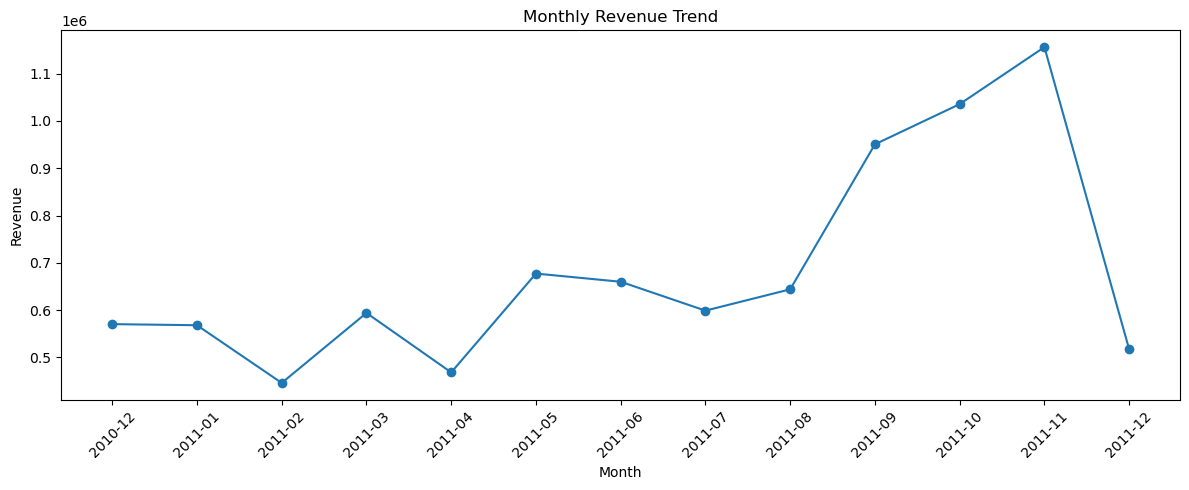

In [40]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue["YearMonth"], monthly_revenue["TotalPrice"], marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

figure_path = FIGURES_DIR / "monthly_revenue_trend.png"
plt.savefig(figure_path, dpi=300)

### Insight: Monthly Revenue

Revenue fluctuates across months. The monthly trend helps identify seasonal patterns and peak sales periods. These insights can support campaign planning, inventory management, and promotion timing.

In [41]:
country_revenue = (
    df_clean
    .groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208952.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64

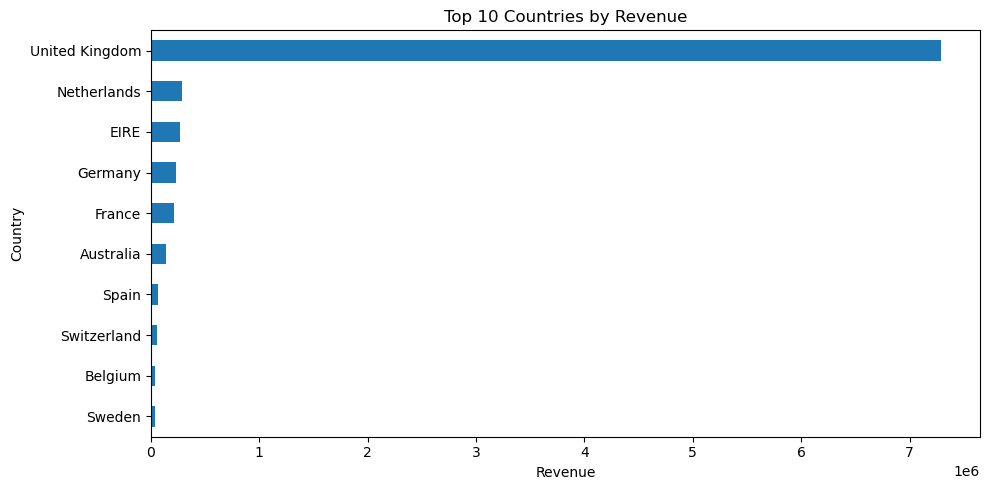

In [42]:
plt.figure(figsize=(10, 5))
country_revenue.sort_values().plot(kind='barh')
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()

figure_path = FIGURES_DIR / "top_10_countries_by_revenue.png"
plt.savefig(figure_path, dpi=300)
plt.show()


### Insight: Country Revenue

Most revenue is concentrated in the top countries. If one country dominates revenue, marketing and operations may be highly dependent on that market.

The United Kingdom contributes the majority of revenue, indicating that the business is highly concentrated in the domestic market.

In [43]:
top_products_quantity = (
    df_clean
    .groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_quantity

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

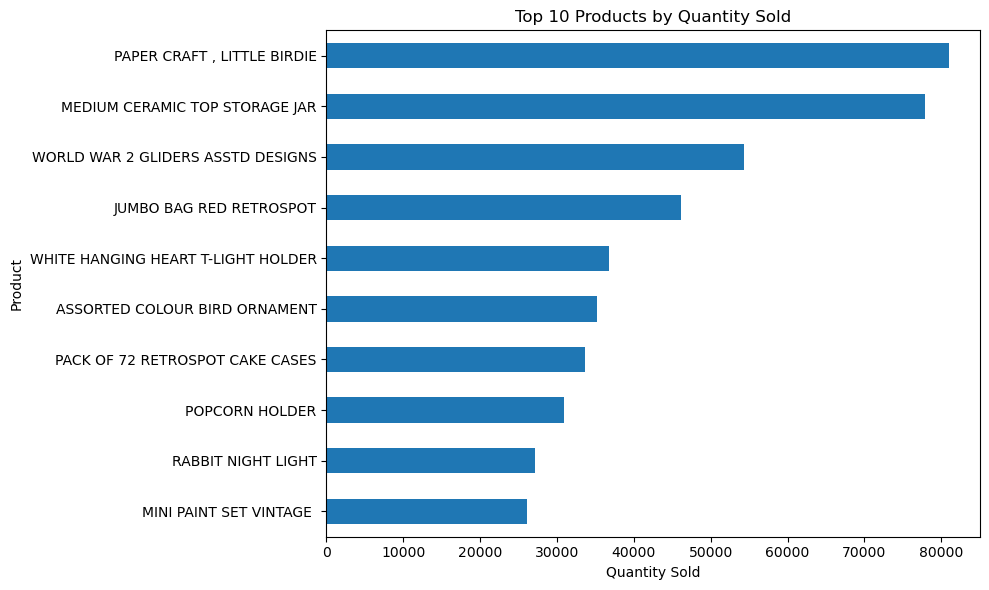

In [44]:
plt.figure(figsize=(10, 6))
top_products_quantity.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()

figure_path = FIGURES_DIR / "top_10_products_by_quantity.png"
plt.savefig(figure_path, dpi=300)
plt.show()

In [45]:
top_products_revenue = (
    df_clean
    .groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_revenue

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77821.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: TotalPrice, dtype: float64

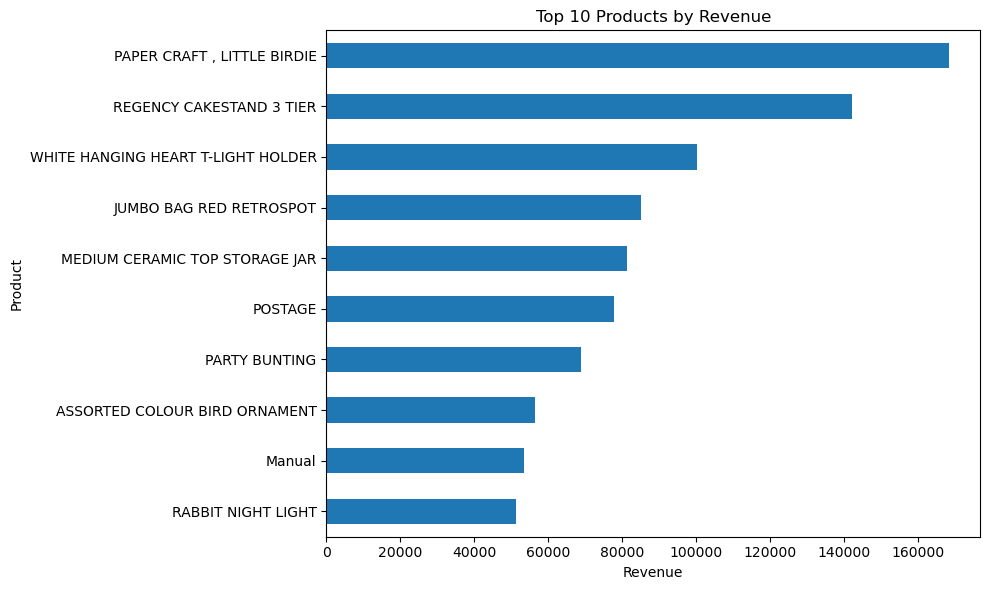

In [46]:
plt.figure(figsize=(10, 6))
top_products_revenue.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()

figure_path = FIGURES_DIR / "top_10_products_by_revenue.png"
plt.savefig(figure_path, dpi=300)
plt.show()

### Insight: Product Performance

The best-selling products by quantity are not always the highest revenue-generating products. Comparing quantity and revenue helps identify products that are popular versus products that are financially valuable.

In [47]:
customer_spending = (
    df_clean
    .groupby("CustomerID")["TotalPrice"]
    .sum()
    .reset_index(name="TotalSpending")
)

customer_spending.describe()

,TotalSpending
count,4338.000000
mean,2048.692230
std,8985.229676
min,3.750000
25%,306.482500
50%,668.570000
75%,1660.597500
max,280206.020000


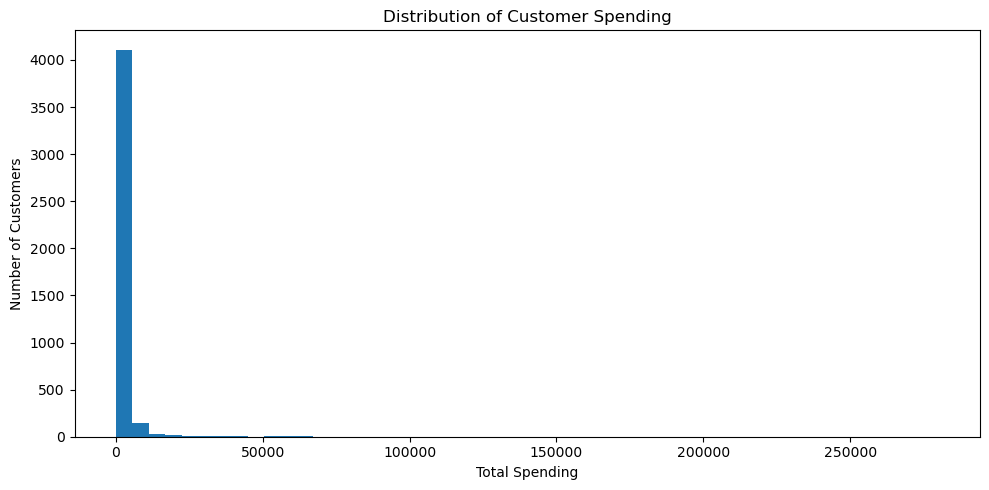

In [48]:
plt.figure(figsize=(10, 5))
plt.hist(customer_spending["TotalSpending"], bins=50)
plt.title("Distribution of Customer Spending")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")
plt.tight_layout()

figure_path = FIGURES_DIR / "customer_spending_distribution.png"
plt.savefig(figure_path, dpi=300)
plt.show()

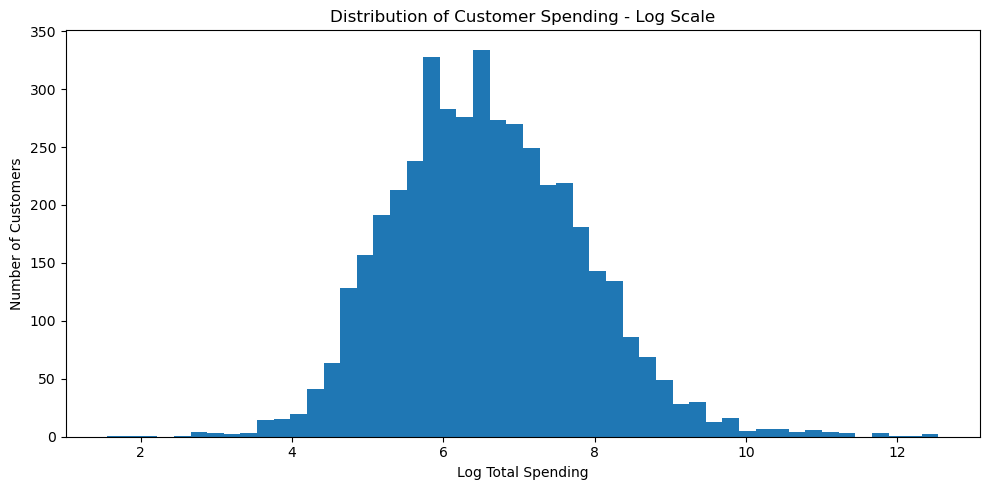

In [49]:
plt.figure(figsize=(10, 5))
plt.hist(np.log1p(customer_spending["TotalSpending"]), bins=50)
plt.title("Distribution of Customer Spending - Log Scale")
plt.xlabel("Log Total Spending")
plt.ylabel("Number of Customers")
plt.tight_layout()

figure_path = FIGURES_DIR / "customer_spending_distribution_log.png"
plt.savefig(figure_path, dpi=300)
plt.show()

### Insight: Customer Spending Distribution

Customer spending is usually highly skewed, meaning a small number of customers spend significantly more than the majority. This supports the need for customer segmentation and VIP customer analysis.

In [50]:
order_value = (
    df_clean
    .groupby("InvoiceNo")["TotalPrice"]
    .sum()
    .reset_index(name="OrderValue")
)

order_value.describe()

,OrderValue
count,18532.000000
mean,479.561132
std,1678.082452
min,0.380000
25%,157.340000
50%,302.575000
75%,469.570000
max,168469.600000


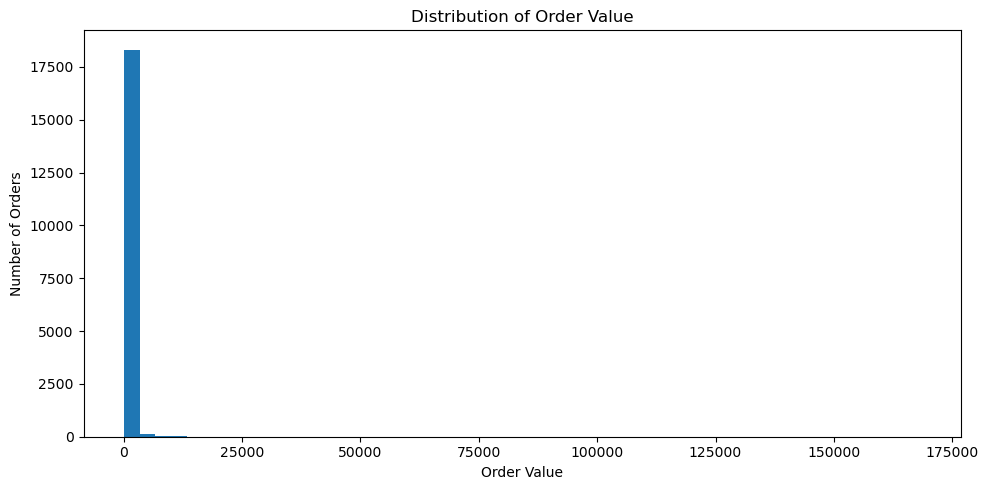

In [51]:
plt.figure(figsize=(10, 5))
plt.hist(order_value["OrderValue"], bins=50)
plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Number of Orders")
plt.tight_layout()

figure_path = FIGURES_DIR / "order_value_distribution.png"
plt.savefig(figure_path, dpi=300)
plt.show()

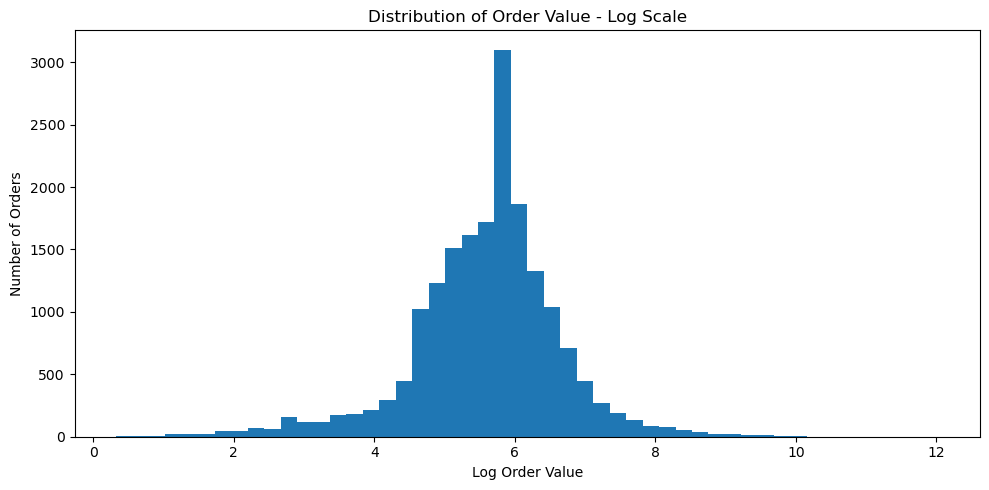

In [52]:
plt.figure(figsize=(10, 5))
plt.hist(np.log1p(order_value["OrderValue"]), bins=50)
plt.title("Distribution of Order Value - Log Scale")
plt.xlabel("Log Order Value")
plt.ylabel("Number of Orders")
plt.tight_layout()

figure_path = FIGURES_DIR / "order_value_distribution_log.png"
plt.savefig(figure_path, dpi=300)
plt.show()

In [53]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

orders_by_day = (
    df_clean
    .drop_duplicates("InvoiceNo")
    .groupby("InvoiceDayOfWeek")["InvoiceNo"]
    .count()
    .reindex(day_order)
)

orders_by_day

InvoiceDayOfWeek
Monday       2863.0
Tuesday      3184.0
Wednesday    3455.0
Thursday     4032.0
Friday       2829.0
Saturday        NaN
Sunday       2169.0
Name: InvoiceNo, dtype: float64

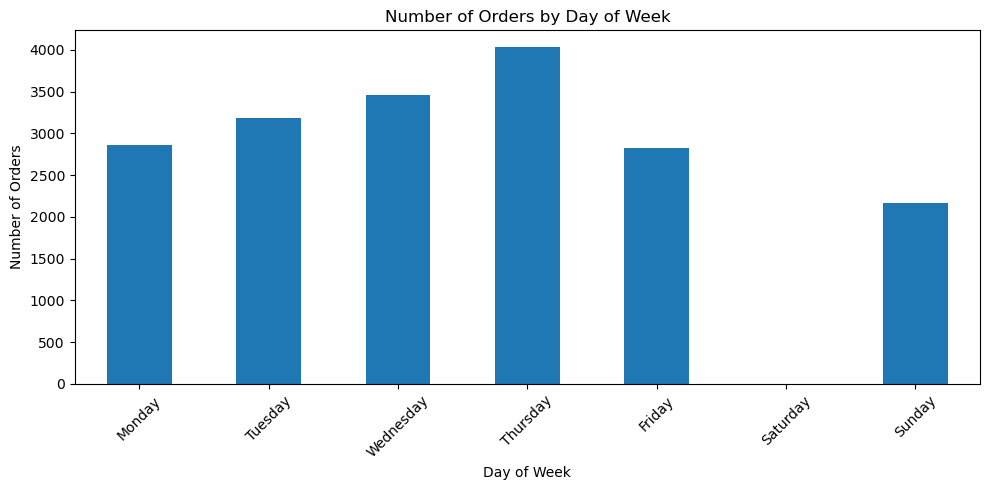

In [54]:
plt.figure(figsize=(10, 5))
orders_by_day.plot(kind="bar")
plt.title("Number of Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()

figure_path = FIGURES_DIR / "orders_by_day_of_week.png"
plt.savefig(figure_path, dpi=300)
plt.show()

### Insight: Orders by Day of Week

Order volume varies across days of the week. This can help identify the best days for promotions, email campaigns, or operational planning.

In [55]:
orders_by_hour = (
    df_clean
    .drop_duplicates("InvoiceNo")
    .groupby("InvoiceHour")["InvoiceNo"]
    .count()
)

orders_by_hour

InvoiceHour
6        1
7       29
8      555
9     1393
10    2226
11    2277
12    3129
13    2636
14    2274
15    2037
16    1100
17     544
18     169
19     144
20      18
Name: InvoiceNo, dtype: int64

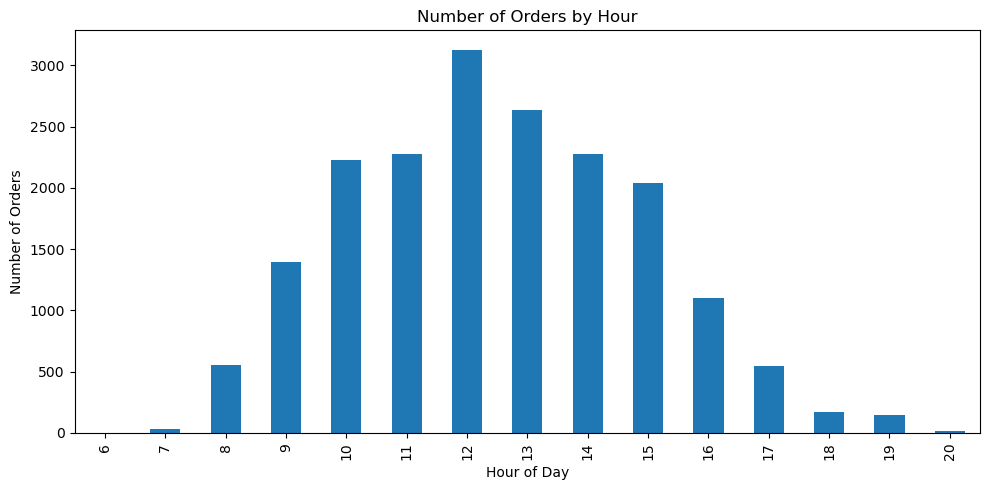

In [56]:
plt.figure(figsize=(10, 5))
orders_by_hour.plot(kind="bar")
plt.title("Number of Orders by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.tight_layout()

figure_path = FIGURES_DIR / "orders_by_hour.png"
plt.savefig(figure_path, dpi=300)
plt.show()

### Insight: Orders by Hour

Order volume by hour helps identify peak purchasing times. Marketing messages or promotional campaigns can be scheduled around periods with higher customer activity.

## EDA Summary

Key findings from the exploratory data analysis:

1. Revenue is concentrated in a small number of countries, with the main market contributing the majority of revenue.
2. Some products dominate by quantity sold, while others generate higher revenue due to higher unit prices.
3. Customer spending is highly skewed, indicating that a small group of customers contributes disproportionately to revenue.
4. Order values also show a skewed distribution, suggesting the presence of high-value orders.
5. Time-based analysis shows purchasing patterns by month, day of week, and hour.

These findings support the next step: RFM analysis and customer segmentation.